<a href="https://colab.research.google.com/github/LuisaCamargoVega/An-lisis-de-Datos-del-Cat-logo-de-Amazon-Prime-con-Python/blob/main/Amazon_Prime_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/amazon_prime_movies_tv_2025.csv')

In [ ]:
##Exploracion inicial de datos

print(df.info())

# Dimensiones
print(df.shape)

# Valores nulos
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Title                 1000 non-null   object 
 1   Genre(s)              1000 non-null   object 
 2   Type                  1000 non-null   object 
 3   Release Year          1000 non-null   int64  
 4   Duration              1000 non-null   object 
 5   Language              1000 non-null   object 
 6   Country of origin     1000 non-null   object 
 7   Director/Creator      1000 non-null   object 
 8   Cast                  1000 non-null   object 
 9   IMDb Score            1000 non-null   float64
 10  Number of IMDb Votes  1000 non-null   int64  
 11  Description/Synopsis  1000 non-null   object 
 12  Age Rating            1000 non-null   object 
 13  Amazon Prime URL      1000 non-null   object 
 14  Is Available          1000 non-null   bool   
 15  Genre sub-tags        

In [ ]:
# Eliminar duplicados

df = df.drop_duplicates()

# Eliminar columnas completamente vacías

df = df.dropna(axis=1, how='all')

# Rellenar valores faltantes

df = df.fillna('Desconocido')

print(df.head())

                           Title     Genre(s)     Type  Release Year  \
0                      Hanna 963        Drama    Movie          2012   
1             The Peripheral 549       Comedy    Movie          2005   
2  The Marvelous Mrs. Maisel 274       Action  TV Show          2014   
3                  Jack Ryan 291     Thriller  TV Show          2005   
4          The Terminal List 888  Documentary  TV Show          2017   

      Duration Language Country of origin Director/Creator  \
0   70 minutes   French         Australia       Jane Smith   
1  125 minutes    Hindi           Germany       Jane Smith   
2    5 seasons   German         Australia         John Doe   
3    2 seasons   French           Germany        Bob Brown   
4    6 seasons  Spanish             China        Bob Brown   

                        Cast  IMDb Score  Number of IMDb Votes  \
0  Actor A, Actor E, Actor D         6.0                 47916   
1  Actor A, Actor C, Actor E         6.2                759172

Type
TV Show    520
Movie      480
Name: count, dtype: int64


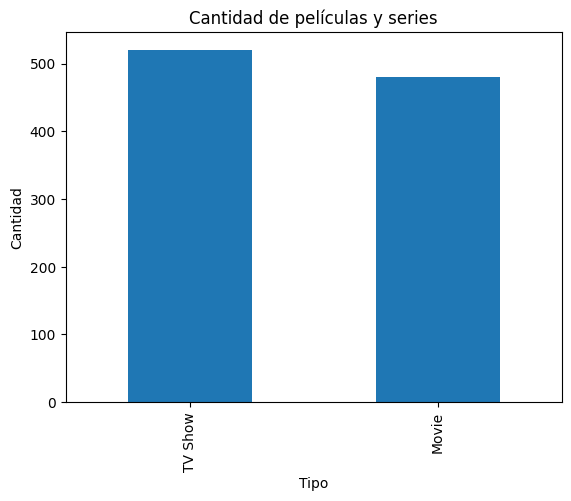

In [ ]:
print(df['Type'].value_counts())

# Gráfico

df['Type'].value_counts().plot(kind='bar')
plt.title('Cantidad de películas y series')
plt.xlabel('Tipo')
plt.ylabel('Cantidad')
plt.show()

Drama          122
Thriller       118
Comedy         116
Action         115
Documentary    115
Sci-Fi         114
Horror         105
Romance        102
Fantasy         93
Name: count, dtype: int64


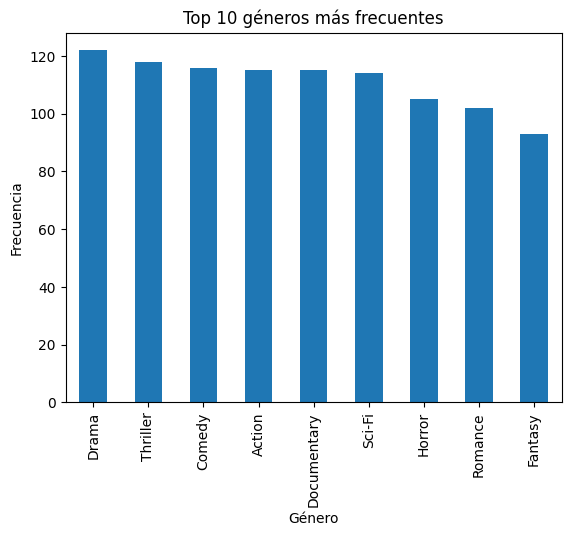

In [ ]:
# Dividir géneros

genres = df['Genre(s)'].str.split(',', expand=True)

# Unir todos los géneros
all_genres = pd.Series(genres.values.ravel())

# Contar frecuencia
print(all_genres.value_counts().head(10))

# Visualización
all_genres.value_counts().head(10).plot(kind='bar')
plt.title('Top 10 géneros más frecuentes')
plt.xlabel('Género')
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
# Convertir rating a numérico

df['IMDb Score'] = pd.to_numeric(df['IMDb Score'], errors='coerce')

# Top 10 mejores películas/series

top_rated = df[['Title', 'IMDb Score']].sort_values(by='IMDb Score', ascending=False).head(10)

print(top_rated)

                              Title  IMDb Score
775    The Underground Railroad 629         9.0
538                   Homecoming 38         9.0
549  The Man in the High Castle 223         9.0
655   The Marvelous Mrs. Maisel 376         9.0
840    The Underground Railroad 786         9.0
232             Without Remorse 342         9.0
195                     The Boys 44         9.0
753             Coming 2 America 93         9.0
503                  Homecoming 944         9.0
239       A League of Their Own 473         9.0


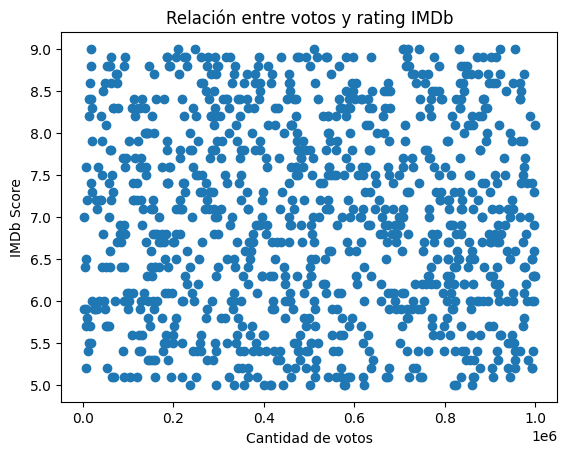

In [ ]:
# Convertir votos a numérico

df['Number of IMDb Votes'] = pd.to_numeric(df['Number of IMDb Votes'], errors='coerce')

# Scatter plot

plt.scatter(df['Number of IMDb Votes'], df['IMDb Score'])
plt.title('Relación entre votos y rating IMDb')
plt.xlabel('Cantidad de votos')
plt.ylabel('IMDb Score')
plt.show()

Country of origin
Canada       7.156604
Australia    7.130097
USA          7.093069
Germany      6.991736
France       6.963793
Japan        6.937815
China        6.921698
India        6.906957
UK           6.797345
Name: IMDb Score, dtype: float64


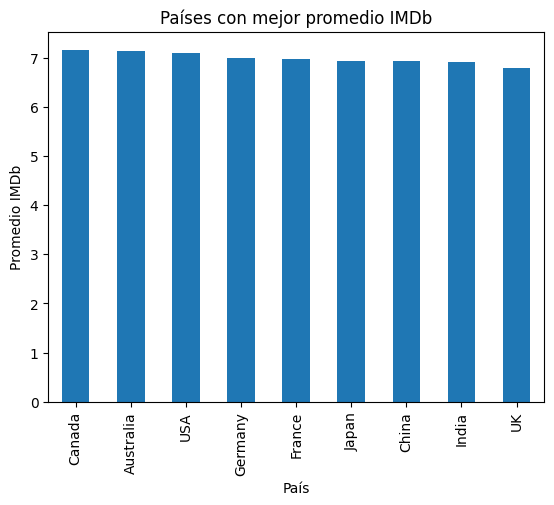

In [ ]:
country_rating = df.groupby('Country of origin')['IMDb Score'].mean().sort_values(ascending=False).head(10)

print(country_rating)

country_rating.plot(kind='bar')
plt.title('Países con mejor promedio IMDb')
plt.xlabel('País')
plt.ylabel('Promedio IMDb')
plt.show()